<p align="center">
    <span style="font-size:2.5em; font-weight:bold;">
        eFleetPlan - Optimal infrastructure and fleet operation of electric LCV
    </span>
</p>

<p align="center">
    <span style="font-size:1.5em; font-weight:bold;">
        Carolina Gil Ribeiro, Jagruti Thakur
    </span>
</p>

## 0. Importing dependencies

In [6]:
from pyomo.opt import SolverFactory 
import pandas as pd
import numpy as np
import xlsxwriter as xl
import matplotlib.pyplot as plt
import os
from glob import glob
from matplotlib import rcParams
from datetime import datetime
from pyomo.opt.results import SolverStatus
import datetime as dt
import math
from typing import Literal
import time
from matplotlib.ticker import MaxNLocator

import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from src.efleetplan._1_schedule.schedule_generator import ScheduleGenerator, generate_fleet_schedules
from src.efleetplan._1_schedule.schedule_configure import scheduletype, vehicletype, companytype
from src.efleetplan._1_schedule.generate_graphs import generate_graphs


from src.efleetplan._2_optimisation.optimisation import optimisation, save_results
from src.efleetplan._2_optimisation.optimisation_graphs import graph_vehicles, plot_summary_table, process_folder, graph_number_of_chargers_by_schedules, graph_chargingenergy, graph_energybytype

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
notebook_dir = os.getcwd()

# 1. SCHEDULE GENERATOR MODULE

## 1.1 Schedyle generator configurations

In this module, the only required input file is the Energy Consumption Factor.
This factor is used to adjust energy consumption values based on changes in temperature, accounting for environmental and operational variations.

The example uses hourly temperature data from the "Stockholm-Observatorielunden A" measurement station, provided by the Swedish Meteorological and Hydrological Institute (SMHI).

In [7]:
# environment arguments - adjust settings if necessary
env_config = {"original_seed": 42,  # Seed for RNG - can be set to None so always random (not recommended)
                    
              # settings below if you want to generate new schedules
              "gen_start_date": "2023-01-01 00:00:00",  # New schedule, start date
              "gen_end_date": "2023-12-31 23:00:00",  # New schedule, end date
              "freq": "h",  # 'h' means hourly frequency, '15min' means 15 minutes frequency, etc.
                                                       
              # path to the CSV file with energy consumption factor (the example if for Stockholm 2023)
              # This value can be adjusted to other locations with hourly temperature data
              "consumption_factor_file" : os.path.join(notebook_dir,"..", "data", "Input", "Energy_consumption_factor_2023.csv")                                          
              }

## 1.2. Fleet parameters configurations


It is possible to generate diferent types of schedules, adjusting different parameters.
Schedule configuration includes: Type of schedule (a or b), Type of vehicle (Catefory 1 - Renault and Category 2 - Toyota) and Company type.

New fleet parameters can be defined/created in the file "schedule_configure.py".

#### Type of Schedule
Schedules are categorised into two types: Type A, which consists of a continuous schedule, and Type B, which includes breaks. Various parameters are established to facilitate realistic modelling of daily logistics schedules, including mean departure and return times, standard deviations, and allowable time ranges.
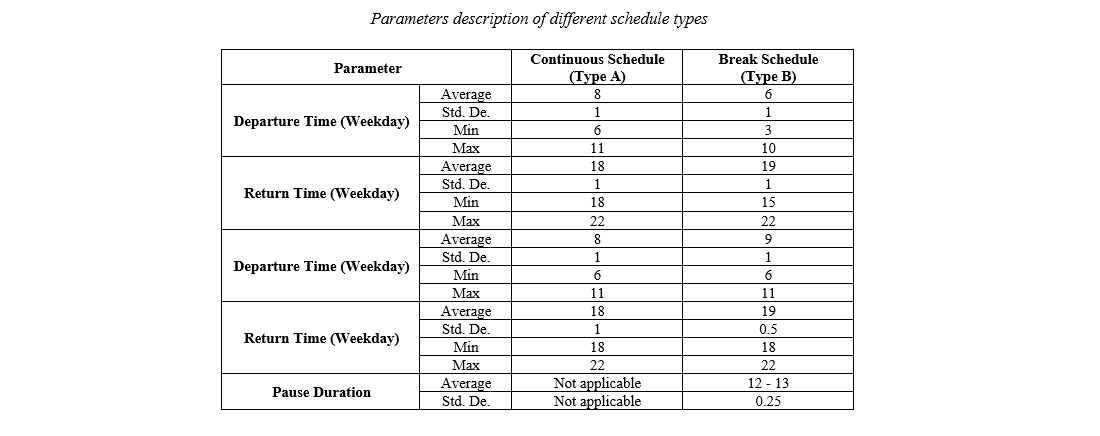

#### Type of vehicle: n_renault and n_toyota

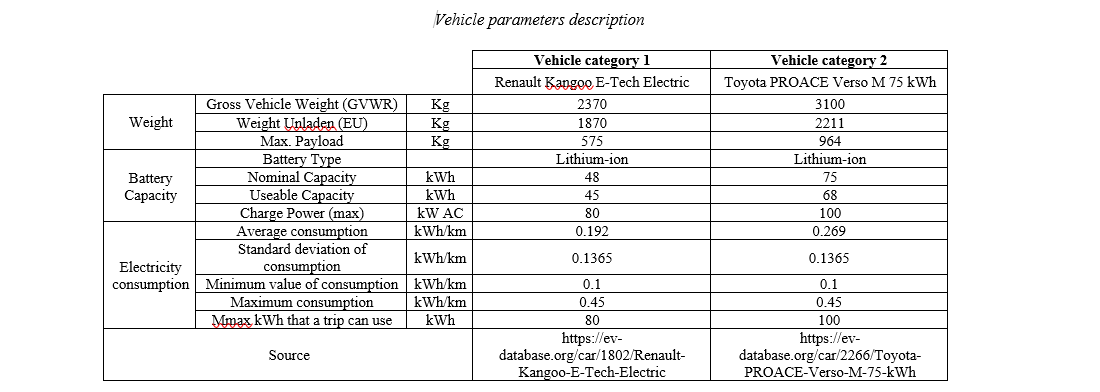

#### Company type
The values related to company type are defined based on the findings of a survey on light goods vehicles in Sweden conducted by Transport Analysis in 2022. 

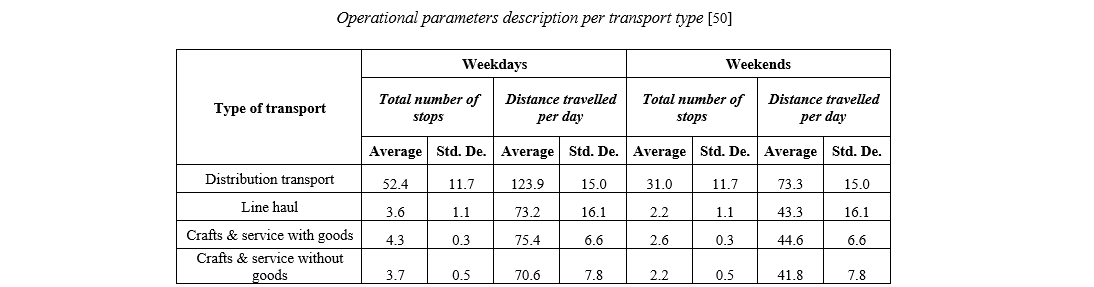

notes: Type of transport is defined as the primary use of the LCV and are described as follows: distribution transport for goods or commodities transports with several stops for loading and unloading along the way; Line haul goods or commodities transports, directly from one place to another;  Crafts and services with goods transports include trips for craft or service vehicle that include goods or merchandise to be used or installed in the work; and crafts and services without goods correspond to craft or service trips without goods or merchandise.

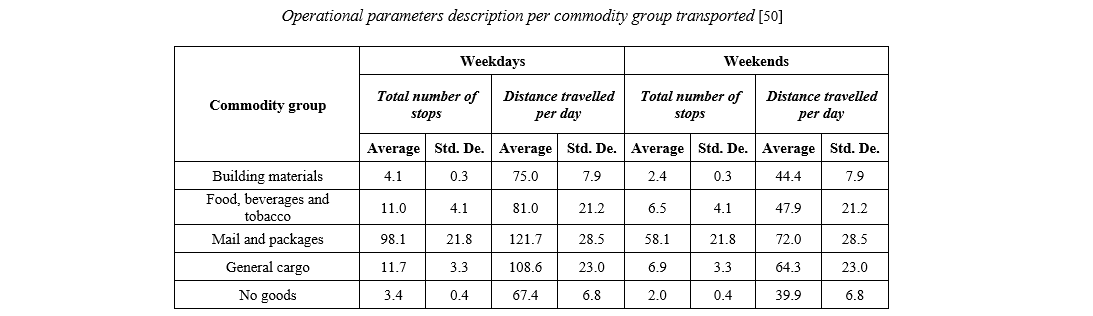

notes: Commodity groups were formulated in Light Goods Vehicles 2022 survey to capture the type of goods commonly transported identified by the vehicles.

### Schedule generator configurations

In [8]:
# Schedule arguments - adjust settings if necessary
sch_config = {"Vehicles number": 50,  # Number of vehicles in the fleet
              
              "Type of schedule": {"type a": 0, "type b": 50, "type c": 0},  # Type A, which consists of a continuous schedule, and Type B, which includes breaks (two-parts), going to the distribution terminal durind the day.
                            
              # Type C is Custom Schedule that needs to be define here:
              
              "Custom Schedule": {"average departure weekday": 8,  # Average departure time on a weekday in hours (0-23)
                                  "std deviation departure weekday": 1,  # Standard deviation of departure time on a weekday in hours
                                  "average return weekday": 18,  # Average return time on a weekday in hours (0-23)
                                  "std deviation return weekday": 1,  # Standard deviation of return time on a weekday in hours
                                  "average departure weekend": 9,  # Average departure time on a weekend in hours (0-23)
                                  "std deviation departure weekend": 1,  # Standard deviation of departure time on a weekend in hours
                                  "average return weekend": 19,  # Average return time on a weekend in hours (0-23)
                                  "std deviation return weekend": 1,  # Standard deviation of return time on a weekend in hours
                                  "minimum departure": 6,  # Minimum departure time in hours (0-23)
                                  "maximum departure": 11,  # Maximum departure time in hours (0-23)
                                  "minimum return": 18,  # Minimum return time in hours (0-23)
                                  "maximum return": 22  # Maximum return time in hours (0-23)
                                  },
              
              "Type of vehicle": {"Renault": 25, "Toyota": 25, "Custom": 0},  # Renault or Toyota or Custom vehicles types
              
              "Custom Vehicle": {"average consumption": 0.2,
                                 "std deviation consumption": 0.1,
                                 "min consumption": 0.1,
                                 "max consumption": 0.3,
                                 "charging power": 60,
                                 "battery capacity": 45  # Battery capacity in kWh
                                 },
              
              "Company type": companytype.Food, # Types of company: Distribution, LineHaul, CraftServWithGoods, CraftServWithoutGoods, Food, Mail, Building, Highdistance, Generalcargo, Nogoods, Custom
              
              #"Company type":Custom,  # Custom company type, if you want to generate a custom schedule with your own distance and stops parameters
              "Custom Distance": {"average weekday":120,  # Average distance traveled on a weekday in km
                                "average weekend": 70,  # Average distance traveled on a weekend in km 
                                "standard deviation weekday": 15,  # Standard deviation of distance traveled on a weekday in km
                                "standard deviation weekend": 15,  # Standard deviation of distance traveled on a weekend in
                                "min distance": 30,  # Minimum distance traveled in km
                                "max distance": 300,  # Maximum distance traveled in km
                                "min distance per hour": 1,  # Minimum distance traveled per hour in km
                                "max distance per hour": 50,  # Maximum distance traveled per hour in km
                                "average stops": 30,  # Average number of stops per day
                                "standard deviation stops": 10  # Standard deviation of number of stops per day
                                },
              
              "Schedule name": 'schedule_2',  # Name of the schedule
              "Schedule number": 2  # Number of the schedule
                }

## 1.3. Schedule Generation

Define the vehicle fleet and type of schedule to generate in the following cell. It is possible to duplicate the cell and generate schedules for different vehicle fleets.

In [9]:
schedule = generate_fleet_schedules(env_config, sch_config)

### Save parameters files in CSV

In [10]:
# Save individual files for each parameter for the schedule
parameters = ['Distance_km', 'Consumption_kWh', 'Consumption_rate_corrected', 'Location', 'ChargingStation', 'PowerRating_kW', 'Battery_Capacity_kWh','ScheduleType', 'consumption_factor']

schedule_name = sch_config["Schedule name"]
schedule_number = sch_config["Schedule number"]
for schedule in [schedule]:
    for parameter in parameters:
        pivoted_schedule = schedule.pivot_table(
            index='date',
            columns='VehicleID',
            values=parameter,
            aggfunc='first'
        )
        pivoted_schedule.columns = [f'{parameter}_Vehicle_{vehicle}' for vehicle in pivoted_schedule.columns]
        pivoted_schedule.reset_index(inplace=True)
        folder_name = f'Schedule_{schedule_number}'
        output_folder = os.path.join(notebook_dir, '..', 'data', 'Output', folder_name)
        if not os.path.exists(output_folder):
            os.makedirs(output_folder)
        file_name = os.path.join(output_folder, f'{schedule_number}_all_vehicles_{parameter}.csv')
        pivoted_schedule.to_csv(file_name, index=False)

In [11]:
print(schedule.head())

                 date  Distance_km  Consumption_kWh  \
0 2023-01-01 00:00:00          0.0              0.0   
1 2023-01-01 01:00:00          0.0              0.0   
2 2023-01-01 02:00:00          0.0              0.0   
3 2023-01-01 03:00:00          0.0              0.0   
4 2023-01-01 04:00:00          0.0              0.0   

   Consumption_rate_corrected  Location  ChargingStation ID  \
0                         0.0         1                1  0   
1                         0.0         1                1  0   
2                         0.0         1                1  0   
3                         0.0         1                1  0   
4                         0.0         1                1  0   

   Battery_capacity_kWh  PowerRating_kW  consumption_factor  \
0                    45              80                 1.0   
1                    45              80                 1.0   
2                    45              80                 1.0   
3                    45              8

## 1.4. Schedules post-processing and visualisation

### Graphs generation per schedule
If you have more than one type of fleet, just need to add the folder name in the next cell.

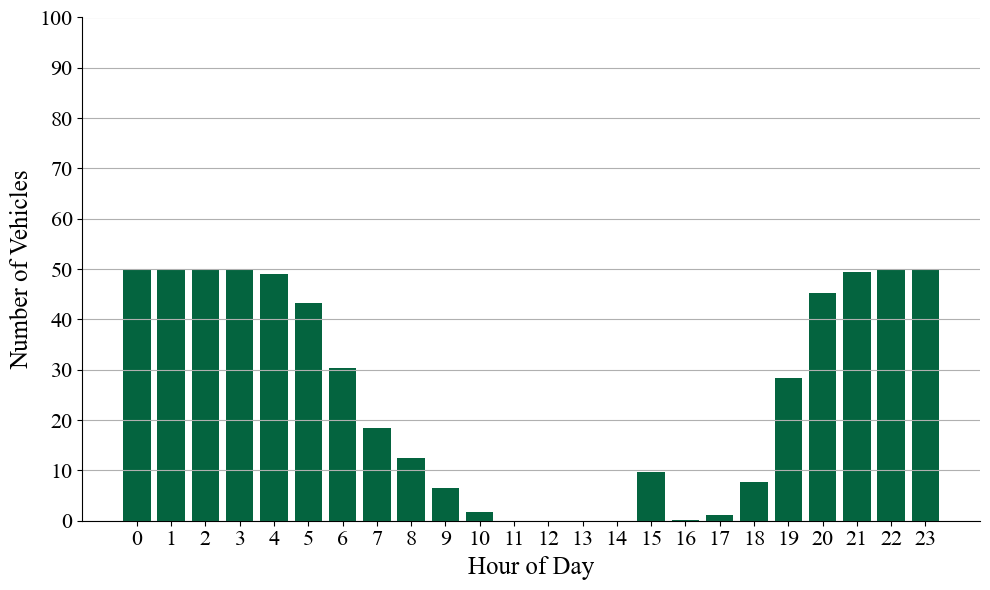

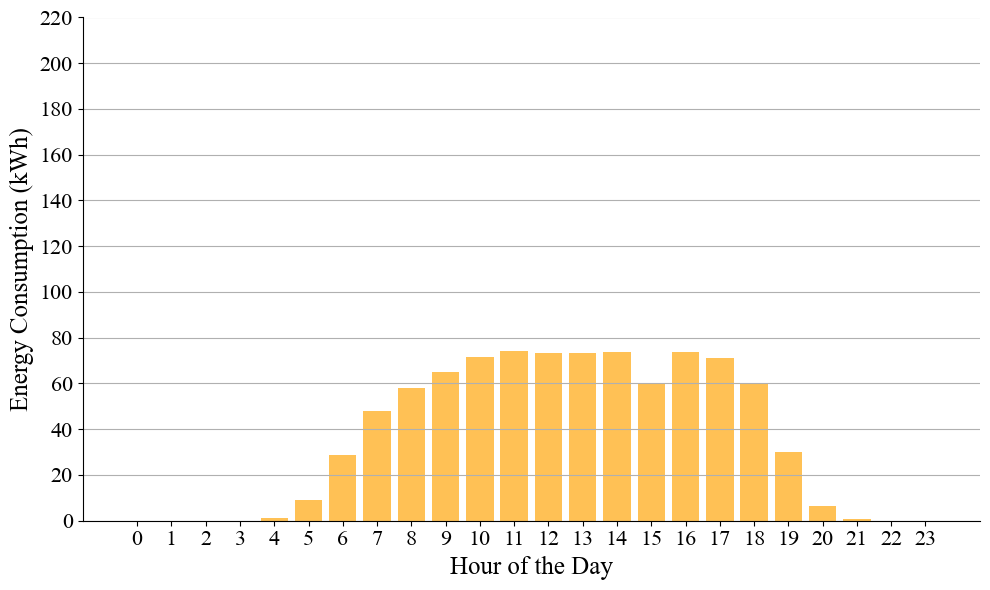

In [12]:
folders = [schedule_name]

for folder in folders:
    schedule_number = folder.split("_")[1]
    output_folder = os.path.join(notebook_dir, '..', 'data', 'Output', folder)
    distance_file_path = os.path.join(output_folder, f'{schedule_number}_all_vehicles_Distance_km.csv')
    charging_file_path = os.path.join(output_folder, f'{schedule_number}_all_vehicles_ChargingStation.csv')
    consumption_file_path = os.path.join(output_folder, f'{schedule_number}_all_vehicles_Consumption_kWh.csv')
    
    generate_graphs(distance_file_path, charging_file_path, consumption_file_path, folder, output_folder)

# 2. Charging Infrastructure co-optimisation Module

## 2.1 optimisation parameters configurations

In [17]:
# environment optimisation arguments - adjust settings if necessary
schedule_name = sch_config["Schedule name"]
schedule_number = sch_config["Schedule number"]

opt_config = {# settings for the optimisation function              
    "opt_start_date": "2023-01-01 00:00:00",  # New schedule, start date
    "opt_end_date": "2023-12-31 23:00:00",    # New schedule, end date
    "freq": "h",                              # 'h' means hourly frequency, 15min means 15 minutes frequency
    "delta_time": 1,                          # is the time step in hour (if the time step is 15 minutes, delta_time=0.25, if the time step is 1 hour, delta_time=1)

    "Schedule name": schedule_name,           # Name of the schedule - used to create input and output folders
    "EVs": 50,                               # Number of electric vehicles in the fleet

    # Input and output folders
    "output_folder": os.path.join(project_root, 'data', 'Output', schedule_name),
    "input_folder": os.path.join(project_root, 'data', 'Input'),

    # CSV file with electricity prices (the example is for SE3 in Stockholm, Sweden)
    "electricity_price_grid": pd.read_csv(os.path.join(project_root, 'data', 'Input', 'SE3_el_prices_2023_modified.csv')),

    # Load the data for the vehicles created in the schedule generator module
    ## Energy consumption file
    "En_consumption": pd.read_csv(os.path.join(project_root, 'data', 'Output', schedule_name, f'{schedule_number}_all_vehicles_Consumption_rate_corrected.csv')),
    ## Distance travel per vehicles and per hour file
    "Ev_distance": pd.read_csv(os.path.join(project_root, 'data', 'Output', schedule_name, f'{schedule_number}_all_vehicles_Distance_km.csv')),
    ## Vehicles availability to charge at the distribution terminal
    "Ev_availability_file": pd.read_csv(os.path.join(project_root, 'data', 'Output', schedule_name, f'{schedule_number}_all_vehicles_ChargingStation.csv')),
    ## Battery capacity - important when the fleet has more than one type of vehicle
    "Battery_Limitation": pd.read_csv(os.path.join(project_root, 'data', 'Output', schedule_name, f'{schedule_number}_all_vehicles_Battery_Capacity_kWh.csv')),
    ## Vehicle battery power - important when the fleet has more than one type of vehicle                                         
    "PowerRate_Limitation": pd.read_csv(os.path.join(project_root, 'data', 'Output', schedule_name, f'{schedule_number}_all_vehicles_PowerRating_kW.csv')),
    "MIPGap": 0.25                            # MIP optimality gap
}

## 2.2. Cost and power configuration

In the cost and power configurations above, it is possible to change the values of different paramenters, related to cost of infrastructure, energy subscription rates, route charging rates and battery power and losses.

In [18]:
power_config = {
    "Charging_losses": 0.964,  # Charging efficiency
    "Battery_Maximum Limit": 0.8,  # Maximum battery limit
    "Battery_Minimum Limit": 0.2,   # Minimum battery limit
    "Accumulated_Cycle_Capacity": 3500,  # Total energy throughput (in kWh) that the battery can handle
    "Charger_Power" : {'s': 7.4, 'Route': 150, 'f1': 50, 'f2': 150, 'f3': 350},  # Charging power of each type of charger
}

In [19]:
cost_config = {"Infrastructure_life": 20, #lifetime or ownership time of the charging infrastructure
               "Infrastructure_cost": {'s': 32000 + 29000, # Slow charger cost
                                       'f1': 294000 + 472000, # Fast charger 50 kw cost
                                       'f2': 778000 + 644000, # Fast charger 150 kw cost
                                       'f3': 1451000 + 1202000}, # Fast charger 350 kw cost
               "maintenance_cost" : {'s': 5000, 'f1': 40000, 'f2': 120000, 'f3': 240000}, # Maintenance cost per type of charger
               "Infrastructure_subscription" : 50,  # SEK/day,
               "Price_FixedrateDT" : 0.0331,
               "Demand_rate" : 1352,
               "Price_FixedrateRoute" : 8.90,
               "Discount_rate": 0.05
               }

## 2.3 Run optimisation

In [20]:
# Call the optimisation function
m, Price, EV_availability, Distance_km = optimisation(opt_config, cost_config, power_config)

Number of days: 365
=== SOLVER CONFIGURATION ===
  MIPGap: 0.25
  ScaleFlag: 2
  LogFile: gurobi_log.txt
  Threads: 8
  Seed: 42
  Method: 2
  Presolve: 2
  NodeMethod: 3
  Cuts: -1
  Heuristics: 0.3
  MIPFocus: 3
       99.80 seconds required to write file
       99.80 seconds required for presolve
Read LP format model from file C:\Users\mcgr2\AppData\Local\Temp\tmpb30gmmg7.pyomo.lp
Reading time = 28.63 seconds
x1: 5524149 rows, 7008307 columns, 15598099 nonzeros
Set parameter MIPGap to value 0.25
Set parameter ScaleFlag to value 2
Set parameter LogFile to value "gurobi_log.txt"
Set parameter Threads to value 8
Set parameter Seed to value 42
Set parameter Method to value 2
Set parameter Presolve to value 2
Set parameter NodeMethod to value 3
Set parameter Cuts to value -1
Set parameter Heuristics to value 0.3
Set parameter MIPFocus to value 3
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 11.0 (26100.2))

CPU model: AMD Ryzen Threadripper PRO 7965WX 24-Cores, instru

### Saving results

In [21]:
# Ensure the output directory exists before saving results
results_folder = os.path.join(project_root, 'data', 'Output', f'{schedule_name}', 'Results')
os.makedirs(results_folder, exist_ok=True)

csv_file_pathA = os.path.join(results_folder, f'{schedule_number}_Main_variables_results.csv')
csv_file_pathB = os.path.join(results_folder, f'{schedule_number}_results_summary.csv')
csv_file_pathC = os.path.join(results_folder, f'{schedule_number}_results_per_EV.csv')
csv_file_pathD = os.path.join(results_folder, f'{schedule_number}_results_per_EV_descriptive.csv')

save_results(m, Price, EV_availability, Distance_km, csv_file_pathA, csv_file_pathB, csv_file_pathC, csv_file_pathD, cost_config, power_config)

✅ Results saved successfully as CSV!


## 2.4. Post-processing and visualisation

c:\Carolina\eFleetPlan\src\efleetplan\_2_optimisation\optimisation_graphs.py:56: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  table_df = df_other.pivot_table(index='Category', columns='Description', values='Value', sort=False)
c:\Carolina\eFleetPlan\src\efleetplan\_2_optimisation\optimisation_graphs.py:57: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  table_dt = df_dt.pivot_table(index='Category', columns='Description', values='Value', sort=False)


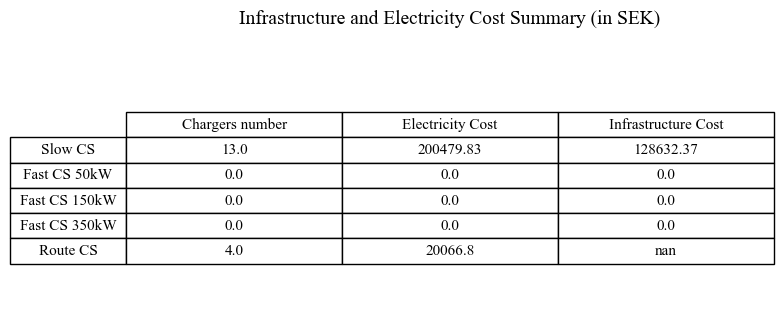

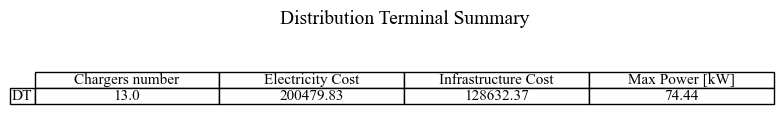

In [22]:
# Set the path to your folder
file_pattern_mean = os.path.join(project_root, 'data', 'Output', f'{schedule_name}', 'Results', '*_results_summary.csv')

# Use glob to find the actual file
matched_files = glob(file_pattern_mean)
if not matched_files:
    raise FileNotFoundError(f"No file matches the pattern: {file_pattern_mean}")
file_path = matched_files[0]


plot_summary_table(file_path)

### Create maximum and average files

In [23]:
# Set the path to your folder
folder_path = os.path.join(project_root, 'data', 'Output', f'{schedule_name}', 'Results')

# Find all files with the pattern *_hourly_averages.csv
filename_pattern = os.path.join(folder_path, '*_Main_variables_results.csv')

process_folder(folder_path, filename_pattern)

Processed 2_Main_variables_results.csv in c:\Carolina\eFleetPlan\data\Output\schedule_2\Results.


2


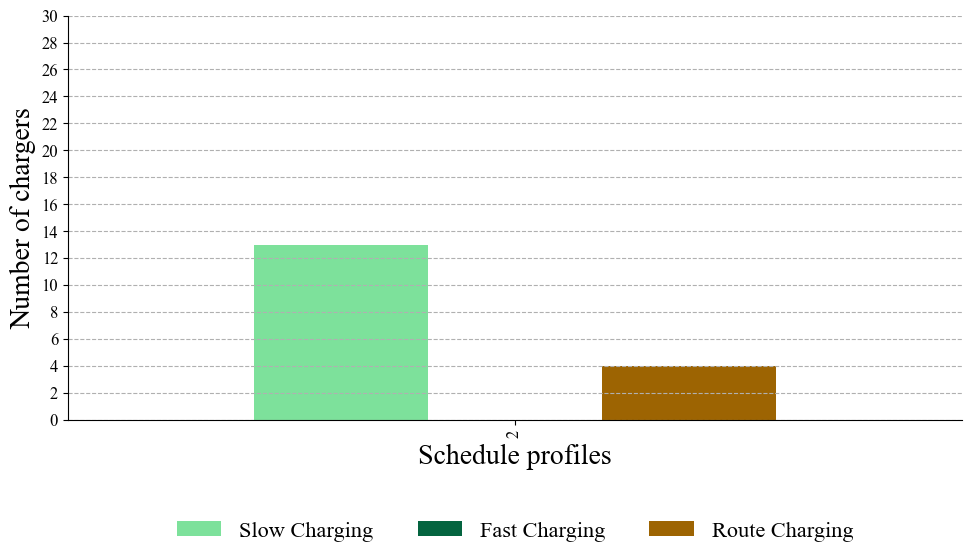

<Figure size 640x480 with 0 Axes>

In [24]:
# Set the path to your folder
folder_path = os.path.join(project_root, 'data', 'Output', f'{schedule_name}', 'Results')
file_pattern_max = os.path.join(project_root, 'data', 'Output', f'{schedule_name}', 'Results', '*_max_variable_per_hour.csv')
files_hourly_max = glob(file_pattern_max)

graph1 = graph_number_of_chargers_by_schedules(folder_path, files_hourly_max)

### Graph 2 - Average charging power and average price of electricity

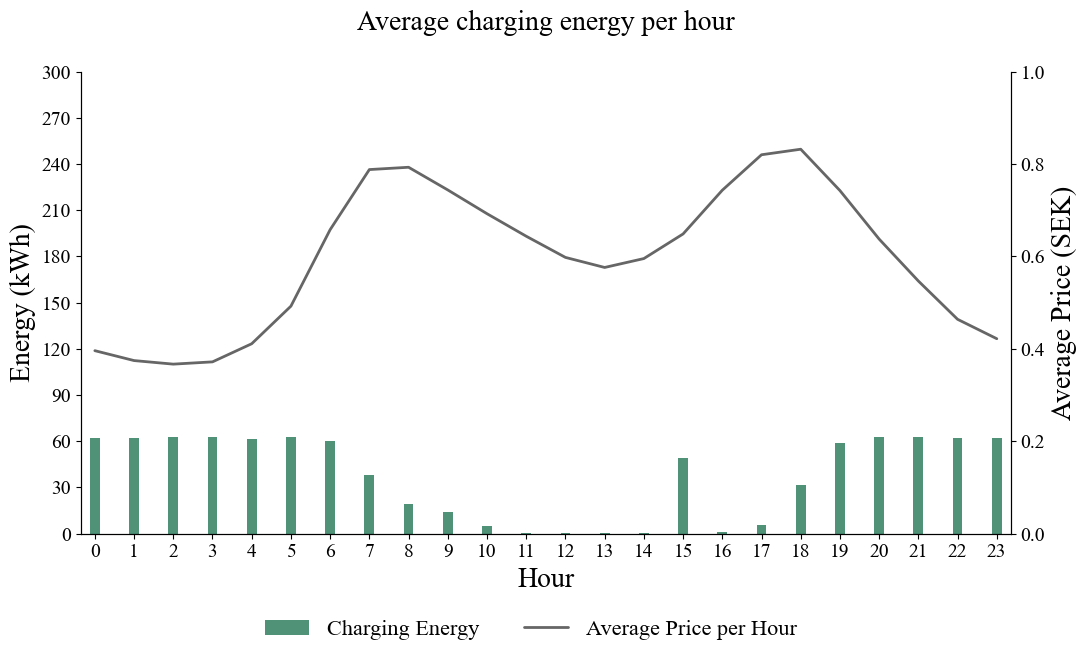

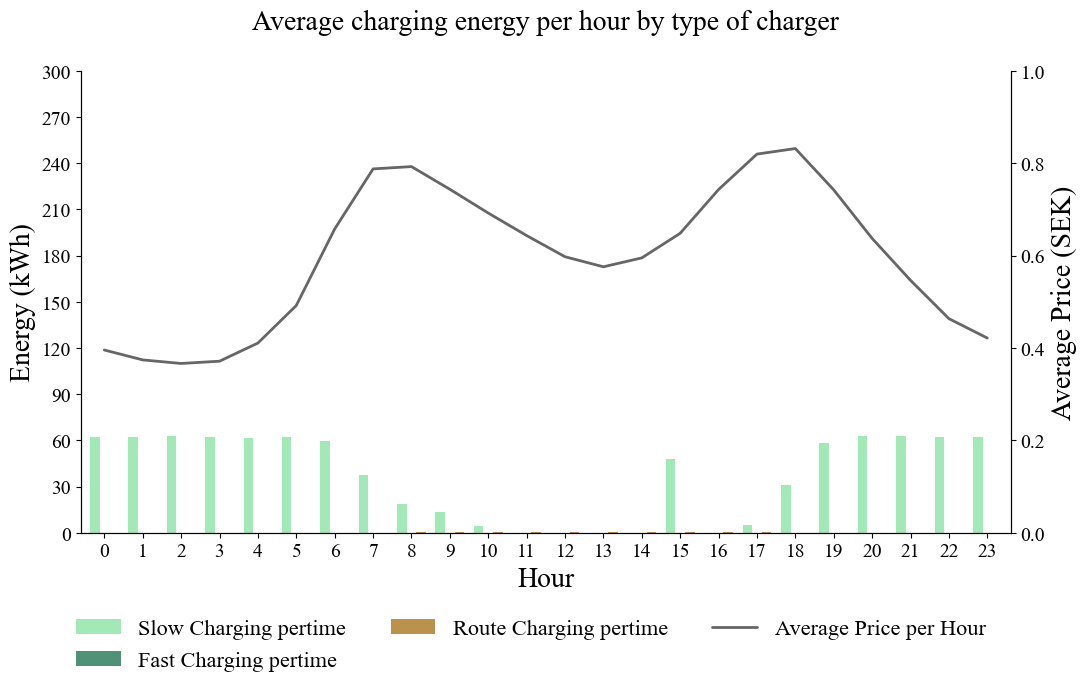

(<Axes: xlabel='Hour', ylabel='Energy (kWh)'>,
 <Axes: title={'center': 'Average charging energy per hour by type of charger'}, ylabel='Average Price (SEK)'>)

In [25]:
# Set the path to your folder
file_pattern_mean = os.path.join(project_root, 'data', 'Output', f'{schedule_name}', 'Results', '*_avg_variable_per_hour.csv')
# Use glob to find the actual file

matched_files = glob(file_pattern_mean)
if not matched_files:
    raise FileNotFoundError(f"No file matches the pattern: {file_pattern_mean}")
file_path = matched_files[0]
folder_path = os.path.join(project_root, 'data', 'Output', f'{schedule_name}', 'Results')

graph_chargingenergy(file_path, folder_path)

graph_energybytype(file_path, folder_path)

### Graph 3 - Charging, discharging power and SOC

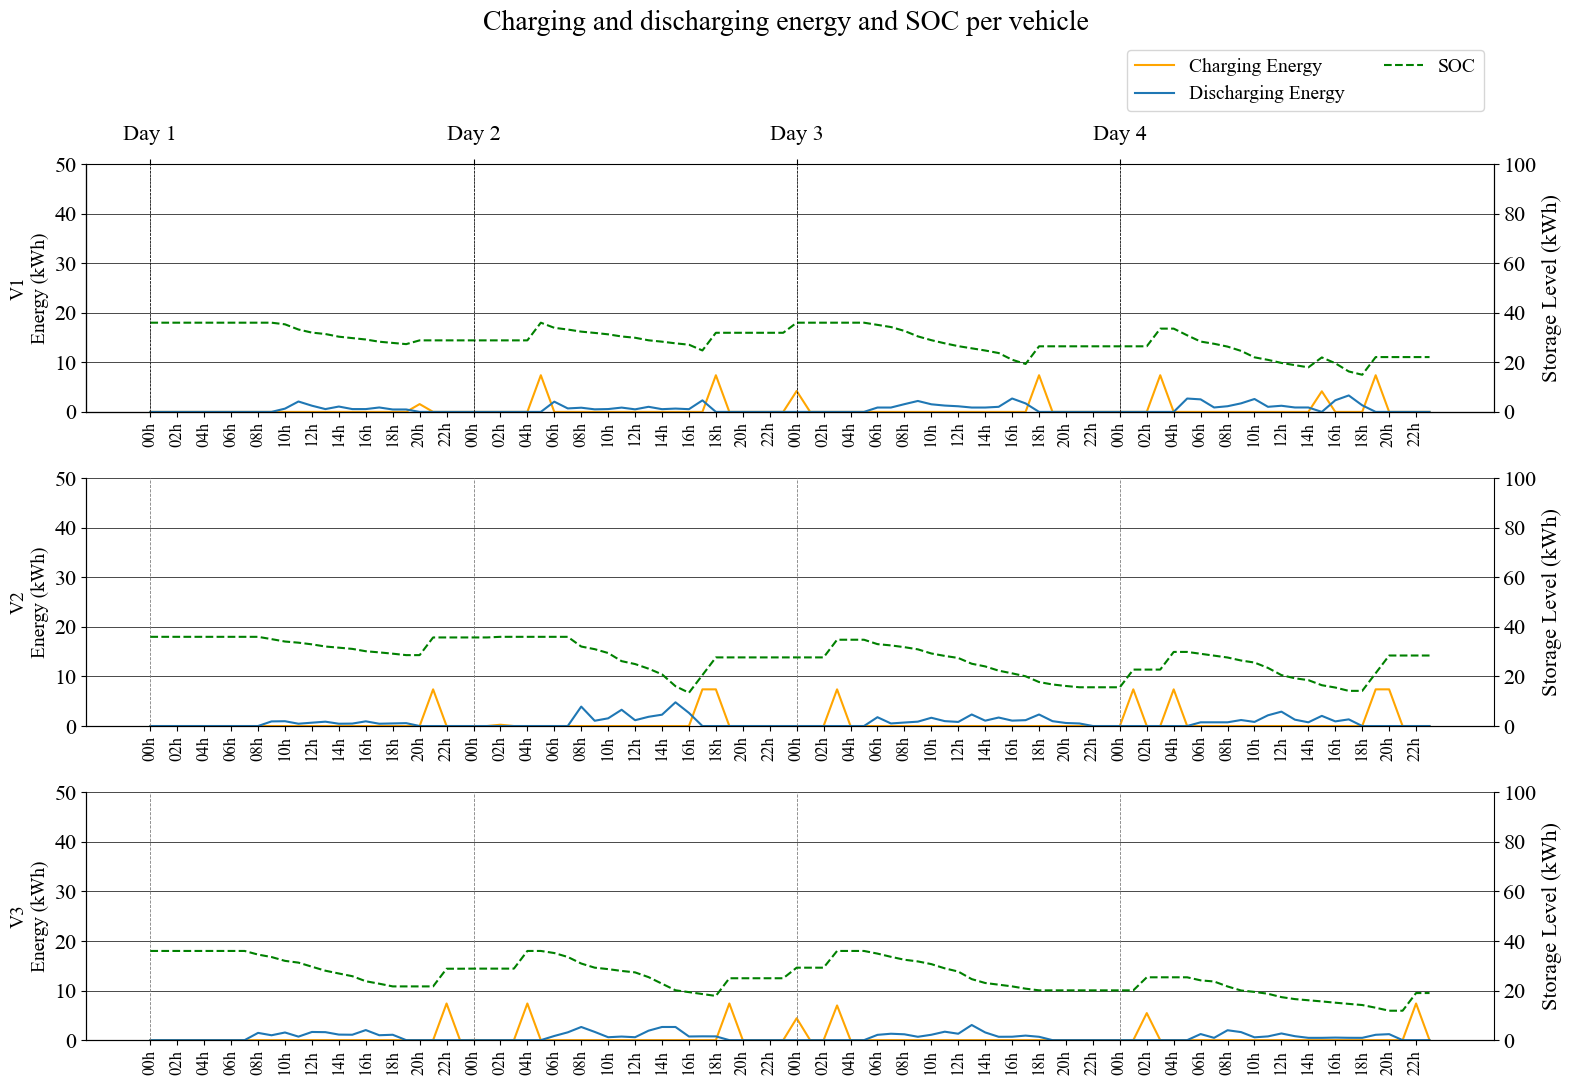

In [26]:
# Set the path to your folder
file_path = csv_file_pathD

# Set the number of vehicles for the graph
n_vehicles = 3
# Set the number of days for the graph
n_days = 4

graph_vehicles(folder_path, file_path, n_days, n_vehicles)